# Layer 1 (Ghana, 2020): Surface-Type Analysis

This notebook builds **Layer 1 labels** (paved vs unpaved) for Ghana and evaluates whether 2020 Sentinel-2 indices can explain/predict those labels.

## Scope
- Country: Ghana
- Year: 2020 only
- Labels source: HEIGIT Ghana road surface dataset (`heigit_gha_roadsurface_lines.gpkg`)
- Features source: Sentinel-derived road indices from `data/ghana_parquet`

## Layer definition used here
- **Layer 1A (OSM label):** from OSM-based surface class (`osm_surface_class` / `surface`)
- **Layer 1B (DL label):** from model prediction fields (`pred_class` / `pred_label`)
- **Layer 1 final label:** OSM label first; if missing, fallback to DL label


In [3]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid')

DATA_DIR = Path('/Users/miranda/Documents/GitHub/Sentinel-FYP/data')
HEIGIT_PATH = DATA_DIR / 'heigit_gha_roadsurface_lines.gpkg'
S2_PARQUET_DIR = DATA_DIR / 'ghana_parquet'

print('HEIGIT exists:', HEIGIT_PATH.exists())
print('S2 parquet exists:', S2_PARQUET_DIR.exists())

HEIGIT exists: True
S2 parquet exists: True


In [4]:
# Load HEIGIT Ghana road-surface dataset
roads = gpd.read_file(HEIGIT_PATH)
print('Rows:', len(roads))
print('Columns:', list(roads.columns))
roads.head(3)

Rows: 458397
Columns: ['continent', 'country_iso_a2', 'country_iso_a3', 'urban', 'urban_area', 'osm_id', 'osm_type', 'highway', 'surface', 'smoothness', 'osm_surface_class', 'pred_class', 'pred_label', 'combined_surface_osm_priority', 'combined_surface_DL_priority', 'osm_changeset_timestamp', 'DL_mean_timestamp', 'osm_length', 'predicted_length', 'n_of_predictions_used', 'name', 'name:en', 'width', 'lanes', 'oneway', 'bridge', 'layer', 'source', 'geometry']


,continent,country_iso_a2,country_iso_a3,urban,urban_area,osm_id,osm_type,highway,surface,smoothness,...,n_of_predictions_used,name,name:en,width,lanes,oneway,bridge,layer,source,geometry
0,africa,GH,['GHA'],NaN,Accra,42781718.0,ways_line,residential,None,None,...,NaN,None,None,None,None,None,None,None,None,"LINESTRING (-0.25146 5.60897, -0.25153 5.60866..."
1,africa,GH,['GHA'],NaN,Takoradi,632022573.0,ways_line,residential,None,None,...,NaN,None,None,None,None,None,None,None,None,"LINESTRING (-1.75836 4.94972, -1.75834 4.95011)"
2,africa,GH,['GHA'],NaN,Takoradi,630478561.0,ways_line,residential,None,None,...,NaN,None,None,None,None,None,None,None,None,"LINESTRING (-1.75378 4.96109, -1.75386 4.96124..."


In [5]:
# Standardize IDs and build Layer-1 label fields
roads = roads.copy()
roads['osm_id'] = roads['osm_id'].astype(str)

# Helper mappers
PAVED_KEYS = {'paved', 'asphalt', 'concrete', 'sealed'}
UNPAVED_KEYS = {'unpaved', 'gravel', 'dirt', 'earth', 'ground', 'mud', 'sand', 'compacted'}

def map_surface_text(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in PAVED_KEYS:
        return 'paved'
    if s in UNPAVED_KEYS:
        return 'unpaved'
    if 'paved' in s and 'unpaved' not in s:
        return 'paved'
    if 'unpaved' in s or 'gravel' in s or 'dirt' in s or 'earth' in s:
        return 'unpaved'
    return np.nan

def map_pred(v):
    if pd.isna(v):
        return np.nan
    s = str(v).strip().lower()
    if s in {'paved', '0'}:
        return 'paved'
    if s in {'unpaved', '1'}:
        return 'unpaved'
    return np.nan

# OSM-driven label candidates
roads['label_osm_1'] = roads['osm_surface_class'].map(map_surface_text) if 'osm_surface_class' in roads.columns else np.nan
roads['label_osm_2'] = roads['surface'].map(map_surface_text) if 'surface' in roads.columns else np.nan
roads['label_osm'] = roads['label_osm_1'].fillna(roads['label_osm_2'])

# DL-driven label candidates
roads['label_dl_1'] = roads['pred_class'].map(map_pred) if 'pred_class' in roads.columns else np.nan
roads['label_dl_2'] = roads['pred_label'].map(map_pred) if 'pred_label' in roads.columns else np.nan
roads['label_dl'] = roads['label_dl_1'].fillna(roads['label_dl_2'])

# If combined fields exist, use them as stronger fallback
if 'combined_surface_osm_priority' in roads.columns:
    roads['label_comb_osm'] = roads['combined_surface_osm_priority'].map(map_surface_text)
else:
    roads['label_comb_osm'] = np.nan

if 'combined_surface_DL_priority' in roads.columns:
    roads['label_comb_dl'] = roads['combined_surface_DL_priority'].map(map_surface_text)
else:
    roads['label_comb_dl'] = np.nan

# Final Layer-1 label: OSM priority -> combined OSM -> DL -> combined DL
roads['layer1_label'] = (
    roads['label_osm']
    .fillna(roads['label_comb_osm'])
    .fillna(roads['label_dl'])
    .fillna(roads['label_comb_dl'])
)

roads['layer1_source'] = np.select(
    [
        roads['label_osm'].notna(),
        roads['label_comb_osm'].notna(),
        roads['label_dl'].notna(),
        roads['label_comb_dl'].notna(),
    ],
    [
        'osm',
        'combined_osm_priority',
        'dl',
        'combined_dl_priority',
    ],
    default='missing'
)

print('Layer1 label counts:')
print(roads['layer1_label'].value_counts(dropna=False))
print('Label source counts:')
print(roads['layer1_source'].value_counts(dropna=False))

Layer1 label counts:
layer1_label
NaN        422333
unpaved     21887
paved       14177
Name: count, dtype: int64
Label source counts:
layer1_source
missing                  422333
osm                       31012
combined_osm_priority      5052
Name: count, dtype: int64


In [6]:
# Keep one record per osm_id for label table (Layer-1 reference table)
# If duplicates exist per osm_id, we keep the first non-missing label by source priority.
source_priority = {
    'osm': 0,
    'combined_osm_priority': 1,
    'dl': 2,
    'combined_dl_priority': 3,
    'missing': 9,
}

label_df = roads[['osm_id', 'layer1_label', 'layer1_source']].copy()
label_df['source_rank'] = label_df['layer1_source'].map(source_priority)
label_df = label_df.sort_values(['osm_id', 'source_rank'])
label_df = label_df.drop_duplicates('osm_id', keep='first').drop(columns='source_rank')

print('Unique osm_id in label table:', label_df['osm_id'].nunique())
label_df.head()

Unique osm_id in label table: 349686


,osm_id,layer1_label,layer1_source
186571,1000042059.0,NaN,missing
289168,1000042060.0,NaN,missing
185741,1000044405.0,NaN,missing
390414,1000044406.0,NaN,missing
284672,1000044407.0,NaN,missing


In [7]:
# Load Sentinel road-indices and keep 2020 only
s2 = pd.read_parquet(S2_PARQUET_DIR)
s2 = s2.copy()
s2['osm_id'] = s2['osm_id'].astype(str)

s2_2020 = s2[s2['year'] == 2020].copy()

idx_cols = ['NDVI', 'NDMI', 'NDBI', 'NDWI', 'BSI']
for c in idx_cols:
    s2_2020[c] = pd.to_numeric(s2_2020[c], errors='coerce')

# Drop rows where all indices are missing
s2_2020 = s2_2020.dropna(subset=idx_cols, how='all').copy()

print('2020 rows:', len(s2_2020))
print('2020 unique osm_id:', s2_2020['osm_id'].nunique())
s2_2020.head(3)

2020 rows: 2387160
2020 unique osm_id: 326546


,osm_id,fclass,quarter,NDVI,NDMI,NDBI,NDWI,BSI,year
0,520162721,trunk,Q1,0.157278,-0.142099,0.142099,-0.269918,0.183079,2020
1,574240962,trunk,Q1,0.089044,-0.130132,0.130132,-0.173877,0.156009,2020
2,574240965,trunk,Q1,0.058767,-0.161057,0.161057,-0.144965,0.174362,2020


In [8]:
# --- FIX: robust osm_id normalization + merge ---
import pandas as pd
import numpy as np

def normalize_osm_id(series):
    s = series.astype("string").str.strip()

    # remove trailing .0 if IDs were read as floats then cast to string
    s = s.str.replace(r"\.0+$", "", regex=True)

    # numeric path (handles scientific notation too)
    num = pd.to_numeric(s, errors="coerce")
    out = pd.Series(pd.NA, index=s.index, dtype="string")
    m = num.notna()
    out.loc[m] = num.loc[m].astype("Int64").astype("string")

    # fallback: extract first digit block from messy strings
    out = out.fillna(s.str.extract(r"(\d+)")[0].astype("string"))
    return out

# 1) Normalize HEIGIT IDs
roads_fix = roads.copy()
roads_fix["osm_id_norm"] = normalize_osm_id(roads_fix["osm_id"])

# 2) Build label table (only rows that actually have labels)
label_df = roads_fix[["osm_id_norm", "layer1_label", "layer1_source"]].copy()
label_df = label_df.dropna(subset=["osm_id_norm", "layer1_label"]).copy()

# source priority for duplicates
source_priority = {
    "osm": 0,
    "combined_osm_priority": 1,
    "dl": 2,
    "combined_dl_priority": 3,
    "missing": 9,
}
label_df["src_rank"] = label_df["layer1_source"].map(source_priority).fillna(9)
label_df = (
    label_df.sort_values(["osm_id_norm", "src_rank"])
            .drop_duplicates("osm_id_norm", keep="first")
            .drop(columns="src_rank")
)

# 3) Normalize S2 IDs
s2_2020_fix = s2_2020.copy()
s2_2020_fix["osm_id_norm"] = normalize_osm_id(s2_2020_fix["osm_id"])

# 4) Quick overlap diagnostics
n_label = label_df["osm_id_norm"].nunique()
n_s2 = s2_2020_fix["osm_id_norm"].nunique()
n_common = len(set(label_df["osm_id_norm"].dropna()) & set(s2_2020_fix["osm_id_norm"].dropna()))

print("Unique label IDs:", n_label)
print("Unique S2 IDs   :", n_s2)
print("Common IDs      :", n_common)

# 5) Merge using normalized ID
df_q = s2_2020_fix.merge(label_df, on="osm_id_norm", how="left")

# keep only paved/unpaved rows for Layer 1
df_q = df_q[df_q["layer1_label"].isin(["paved", "unpaved"])].copy()

print("\nQuarterly merged rows (labeled only):", len(df_q))
print("Quarterly unique roads (labeled only):", df_q["osm_id_norm"].nunique())
print("\nLabel balance (%):")
print(df_q["layer1_label"].value_counts(normalize=True).mul(100).round(2))


Unique label IDs: 28580
Unique S2 IDs   : 326546
Common IDs      : 23747

Quarterly merged rows (labeled only): 172282
Quarterly unique roads (labeled only): 23747

Label balance (%):
layer1_label
unpaved    55.99
paved      44.01
Name: proportion, dtype: float64


In [9]:
# Build per-road 2020 feature table (mean across quarters)
df_road = (
    df_q.groupby(['osm_id', 'layer1_label'], as_index=False)[idx_cols]
    .mean()
)

print('Per-road rows:', len(df_road))
print('Per-road label balance (%):')
print(df_road['layer1_label'].value_counts(normalize=True).mul(100).round(2))

df_road.head()

Per-road rows: 23747
Per-road label balance (%):
layer1_label
unpaved    57.59
paved      42.41
Name: proportion, dtype: float64


,osm_id,layer1_label,NDVI,NDMI,NDBI,NDWI,BSI
0,1000593771,unpaved,0.488968,0.005682,-0.005682,-0.475683,0.022806
1,1000593772,unpaved,0.473726,-0.009305,0.009305,-0.444655,0.028146
2,1000593776,unpaved,0.483420,-0.003973,0.003973,-0.469460,0.031302
3,1000593777,unpaved,0.463095,-0.044299,0.044299,-0.463440,0.067917
4,1000593778,unpaved,0.439995,-0.049897,0.049897,-0.454894,0.074139


## Descriptive Layer-1 analysis (2020)
Below we compare index distributions by paved vs unpaved and summarize class-level means/std.


In [10]:
# Summary stats by label
summary = df_road.groupby('layer1_label')[idx_cols].agg(['mean', 'std', 'median']).round(4)
summary


NDVI                    NDMI                    NDBI          \
                mean     std  median    mean     std  median    mean     std   
layer1_label                                                                   
paved         0.1731  0.1084  0.1437 -0.0980  0.0623 -0.1093  0.0980  0.0623   
unpaved       0.2954  0.1378  0.2795 -0.0625  0.0890 -0.0837  0.0625  0.0890   

                        NDWI                     BSI                  
              median    mean     std  median    mean     std  median  
layer1_label                                                          
paved         0.1093 -0.2354  0.0981 -0.2157  0.1186  0.0546  0.1273  
unpaved       0.0837 -0.3597  0.1098 -0.3694  0.0998  0.0834  0.1211

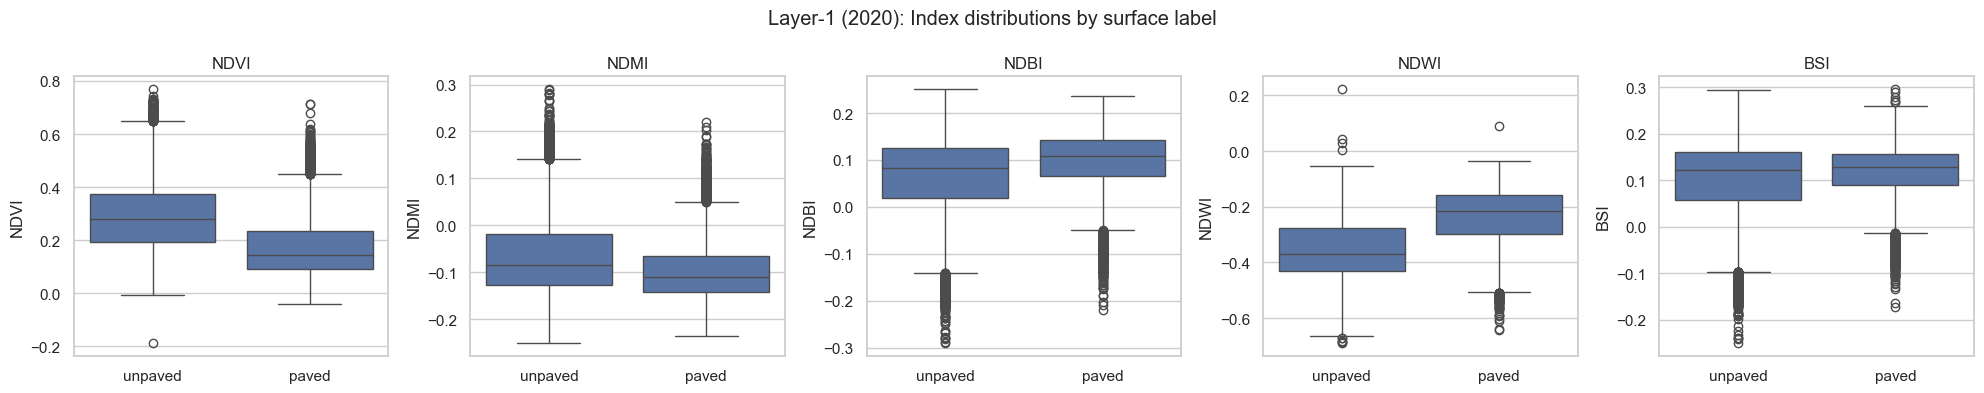

In [11]:
# Boxplots by index (paved vs unpaved)
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, c in zip(axes, idx_cols):
    sns.boxplot(data=df_road, x='layer1_label', y=c, ax=ax)
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('Layer-1 (2020): Index distributions by surface label')
plt.tight_layout()
plt.show()

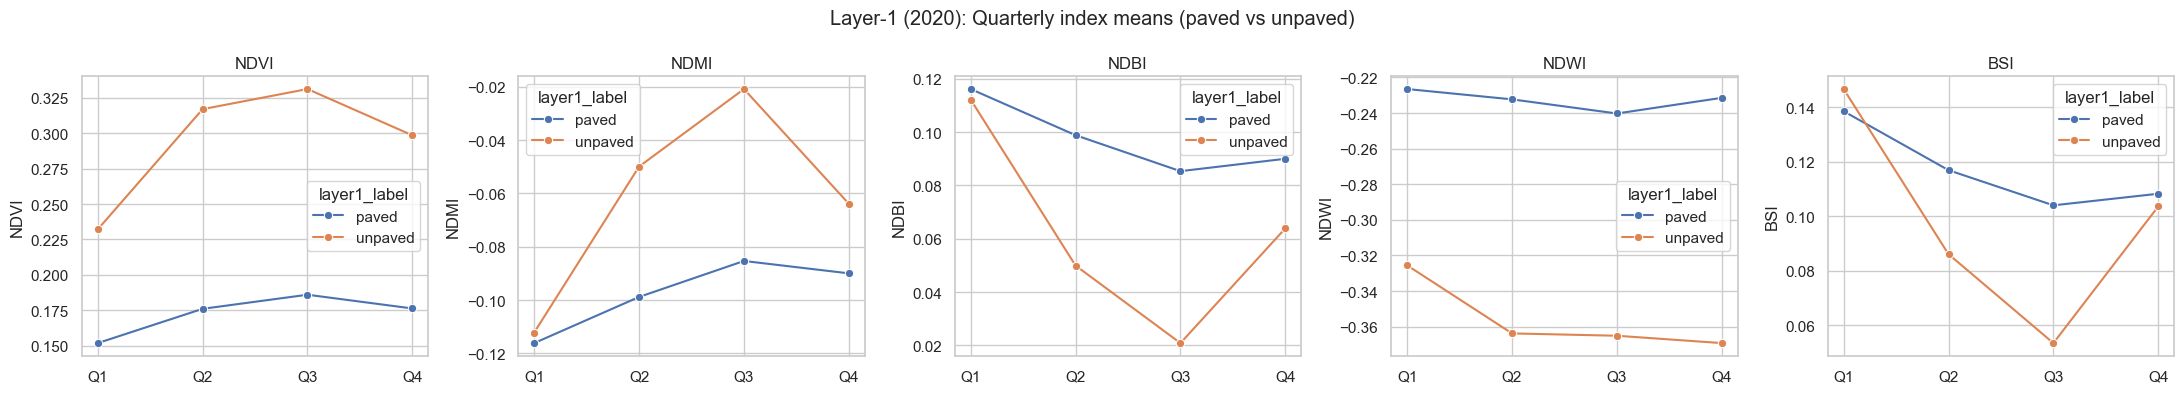

In [12]:
# Quarterly means by label (2020)
q_order = ['Q1', 'Q2', 'Q3', 'Q4']
q_stats = (
    df_q.groupby(['quarter', 'layer1_label'])[idx_cols]
    .mean()
    .reset_index()
)
q_stats['quarter'] = pd.Categorical(q_stats['quarter'], categories=q_order, ordered=True)
q_stats = q_stats.sort_values('quarter')

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharex=True)
for ax, c in zip(axes, idx_cols):
    sns.lineplot(data=q_stats, x='quarter', y=c, hue='layer1_label', marker='o', ax=ax)
    ax.set_title(c)
    ax.set_xlabel('')
plt.suptitle('Layer-1 (2020): Quarterly index means (paved vs unpaved)')
plt.tight_layout()
plt.show()

## Baseline predictive check (Layer 1)
This is not your final model yet. It is a baseline test: can 2020 spectral indices separate paved vs unpaved roads?


              precision    recall  f1-score   support

       paved      0.695     0.665     0.680      2518
     unpaved      0.761     0.785     0.773      3419

    accuracy                          0.734      5937
   macro avg      0.728     0.725     0.726      5937
weighted avg      0.733     0.734     0.733      5937



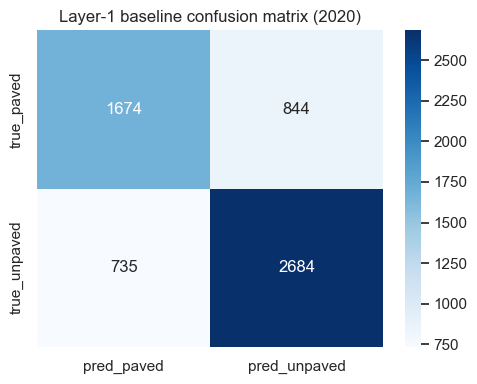

In [13]:
# RandomForest baseline for paved/unpaved
model_df = df_road.dropna(subset=idx_cols).copy()
X = model_df[idx_cols]
y = model_df['layer1_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1,
)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)

print(classification_report(y_test, pred, digits=3))

cm = confusion_matrix(y_test, pred, labels=['paved', 'unpaved'])
cm_df = pd.DataFrame(cm, index=['true_paved', 'true_unpaved'], columns=['pred_paved', 'pred_unpaved'])

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues')
plt.title('Layer-1 baseline confusion matrix (2020)')
plt.tight_layout()
plt.show()

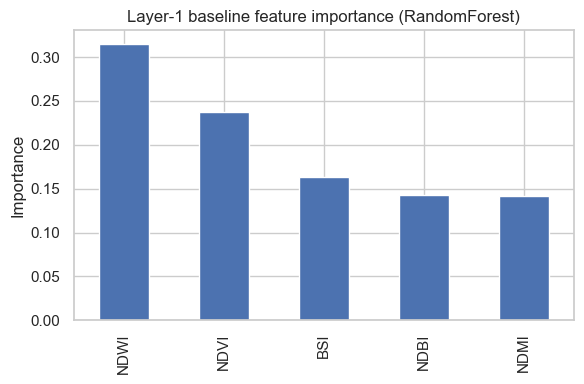

NDWI    0.314618
NDVI    0.236922
BSI     0.163521
NDBI    0.143142
NDMI    0.141797
dtype: float64

In [14]:
# Feature importance
fi = pd.Series(rf.feature_importances_, index=idx_cols).sort_values(ascending=False)

plt.figure(figsize=(6,4))
fi.plot(kind='bar')
plt.title('Layer-1 baseline feature importance (RandomForest)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

fi

## Next step after this notebook
If this Layer-1 baseline is stable, next we can:
1. Expand from 2020 to 2020-2023 with robust cloud handling.
2. Add urban/rural and road-class controls.
3. Move to Layer-2 condition labels (IRI / manual validation sample).


## Layer-1 extension: larger OSM-surface label set (add-on)

This section **adds** a second Layer-1 experiment using the larger OSM surface-derived labels (from Ghana OSM PBF), then runs the same paved vs unpaved baseline.



In [1]:
# Build a larger paved/unpaved label table from Ghana OSM PBF (add-on, does not replace previous section)
from pathlib import Path
import numpy as np
import pandas as pd

try:
    from pyrosm import OSM
except Exception as e:
    raise ImportError("pyrosm is required for this section. Install with: pip install pyrosm") from e

PBF_PATH = Path('/Users/miranda/Documents/GitHub/Sentinel-FYP/data/ghana-260304.osm.pbf')
if not PBF_PATH.exists():
    raise FileNotFoundError(f"PBF not found: {PBF_PATH}")

osm = OSM(str(PBF_PATH))
roads_osm = osm.get_network(network_type='driving')

# Normalize OSM id keys to match Sentinel table
roads_osm = roads_osm.copy()
roads_osm['osm_id'] = roads_osm['id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
roads_osm['surface_clean'] = roads_osm['surface'].astype(str).str.lower().str.strip()

focus_classes = ['residential', 'service', 'trunk', 'primary', 'secondary', 'tertiary', 'unclassified']
roads_osm = roads_osm[roads_osm['highway'].isin(focus_classes)].copy()

# Same paved/unpaved mapping used in analysis2020_2023.ipynb
paved_vals = {
    'paved', 'asphalt', 'concrete', 'paving_stones', 'concrete:plates', 'sett',
    'cobblestone', 'metal', 'bricks', 'cement', 'chipseal'
}
unpaved_vals = {
    'unpaved', 'ground', 'dirt', 'earth', 'gravel', 'fine_gravel', 'sand',
    'mud', 'grass', 'compacted', 'pebblestone', 'soil'
}

roads_osm['layer1_label_large'] = np.where(
    roads_osm['surface_clean'].isin(paved_vals), 'paved',
    np.where(roads_osm['surface_clean'].isin(unpaved_vals), 'unpaved', None)
)

label_df_large = roads_osm[['osm_id', 'highway', 'layer1_label_large']].copy()
label_df_large = label_df_large[label_df_large['layer1_label_large'].isin(['paved', 'unpaved'])]
label_df_large = label_df_large.rename(columns={'highway': 'fclass'})

# One row per OSM id for merge stability
label_df_large = label_df_large.drop_duplicates(subset=['osm_id'])

print('Large label rows:', len(label_df_large))
print('Large label unique osm_id:', label_df_large['osm_id'].nunique())
print('Large label balance (%):')
print(label_df_large['layer1_label_large'].value_counts(normalize=True).mul(100).round(2))


/opt/anaconda3/envs/sentinel/lib/python3.11/site-packages/pyrosm/networks.py:37: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  edges, nodes = prepare_geodataframe(


Large label rows: 29738
Large label unique osm_id: 29738
Large label balance (%):
layer1_label_large
unpaved    57.17
paved      42.83
Name: proportion, dtype: float64


In [15]:
# Merge larger labels with existing S2-2020 table, then aggregate to one row per road
# Assumes s2_2020 already exists from earlier cells in this notebook.

if 's2_2020' not in globals():
    raise NameError('s2_2020 not found. Run the earlier S2 loading cells first.')

s2_tmp = s2_2020.copy()
s2_tmp['osm_id'] = s2_tmp['osm_id'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

df_q_large = s2_tmp.merge(label_df_large[['osm_id', 'layer1_label_large']], on='osm_id', how='inner')

print('Quarterly merged rows (large labels):', len(df_q_large))
print('Quarterly unique roads (large labels):', df_q_large['osm_id'].nunique())

road_feats_large = (
    df_q_large.groupby(['osm_id', 'layer1_label_large'], as_index=False)
    .agg(
        NDVI_mean=('NDVI', 'mean'), NDVI_std=('NDVI', 'std'),
        NDMI_mean=('NDMI', 'mean'), NDMI_std=('NDMI', 'std'),
        NDBI_mean=('NDBI', 'mean'), NDBI_std=('NDBI', 'std'),
        NDWI_mean=('NDWI', 'mean'), NDWI_std=('NDWI', 'std'),
        BSI_mean=('BSI', 'mean'),  BSI_std=('BSI', 'std')
    )
)

feat_cols_large = [
    'NDVI_mean','NDVI_std','NDMI_mean','NDMI_std','NDBI_mean',
    'NDBI_std','NDWI_mean','NDWI_std','BSI_mean','BSI_std'
]
road_feats_large[feat_cols_large] = road_feats_large[feat_cols_large].fillna(0)

print('Road-level rows (large labels):', len(road_feats_large))
road_feats_large.head(3)


Quarterly merged rows (large labels): 210194
Quarterly unique roads (large labels): 29123
Road-level rows (large labels): 29123


,osm_id,layer1_label_large,NDVI_mean,NDVI_std,NDMI_mean,NDMI_std,NDBI_mean,NDBI_std,NDWI_mean,NDWI_std,BSI_mean,BSI_std
0,1000593771,unpaved,0.488968,0.134820,0.005682,0.077260,-0.005682,0.077260,-0.475683,0.110715,0.022806,0.063707
1,1000593772,unpaved,0.473726,0.124106,-0.009305,0.075062,0.009305,0.075062,-0.444655,0.093835,0.028146,0.063028
2,1000593776,unpaved,0.483420,0.113489,-0.003973,0.068111,0.003973,0.068111,-0.469460,0.094625,0.031302,0.055517


Large-label Layer-1 report:
              precision    recall  f1-score   support

       paved      0.752     0.728     0.740      2468
     unpaved      0.805     0.823     0.814      3357

    accuracy                          0.783      5825
   macro avg      0.778     0.776     0.777      5825
weighted avg      0.782     0.783     0.782      5825



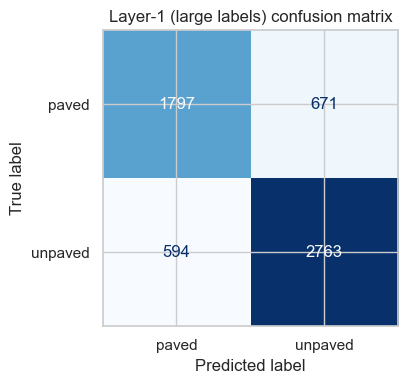

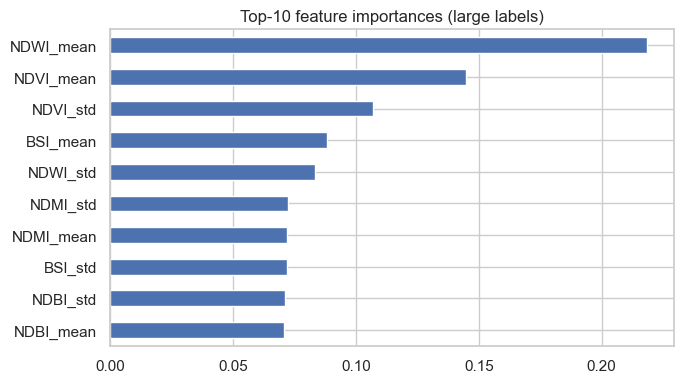

In [16]:
# Layer-1 baseline model on larger labels (RandomForest)
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

X_large = road_feats_large[[
    'NDVI_mean','NDVI_std','NDMI_mean','NDMI_std','NDBI_mean',
    'NDBI_std','NDWI_mean','NDWI_std','BSI_mean','BSI_std'
]].copy()
y_large = road_feats_large['layer1_label_large'].copy()

X_train_l, X_test_l, y_train_l, y_test_l = train_test_split(
    X_large, y_large, test_size=0.2, random_state=42, stratify=y_large
)

rf_large = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf_large.fit(X_train_l, y_train_l)
pred_l = rf_large.predict(X_test_l)

print('Large-label Layer-1 report:')
print(classification_report(y_test_l, pred_l, digits=3))

cm_l = confusion_matrix(y_test_l, pred_l, labels=['paved', 'unpaved'])
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm_l, display_labels=['paved', 'unpaved']).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Layer-1 (large labels) confusion matrix')
plt.tight_layout()
plt.show()

imp_l = pd.Series(rf_large.feature_importances_, index=X_large.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 4))
imp_l.head(10).sort_values().plot(kind='barh', ax=ax)
ax.set_title('Top-10 feature importances (large labels)')
plt.tight_layout()
plt.show()


### Note

This is an **add-on experiment** using a broader OSM-derived paved/unpaved label inventory. Compare these metrics directly against the earlier Layer‑1 section to report whether larger labels improve robustness.

